In [1]:
import os
import shutil
import random
from pathlib import Path

def train_test_split(data_dir, output_dir, test_ratio=0.2, seed=42):
    random.seed(seed)

    # Create train and test directories
    train_dir = Path(output_dir) / 'train'
    test_dir = Path(output_dir) / 'test'
    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    for class_dir in os.listdir(data_dir):
        class_path = Path(data_dir) / class_dir
        if not class_path.is_dir():
            continue

        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))
        random.shuffle(images)

        split_idx = int(len(images) * (1 - test_ratio))
        train_images, test_images = images[:split_idx], images[split_idx:]

        # Create class folders in train and test directories
        (train_dir / class_dir).mkdir(parents=True, exist_ok=True)
        (test_dir / class_dir).mkdir(parents=True, exist_ok=True)

        # Copy images to respective directories
        for img in train_images:
            shutil.copy(img, train_dir / class_dir / img.name)
        for img in test_images:
            shutil.copy(img, test_dir / class_dir / img.name)

        print(f"Class '{class_dir}': {len(train_images)} train, {len(test_images)} test")

if __name__ == "__main__":
    # Change the Number only
    data_dir = "F:\SNAPFOLIA\CLS_DS_59"
    output_dir = "F:\SNAPFOLIA\CLS_DS_59 - SPLIT"
    train_test_split(data_dir, output_dir, test_ratio=0.2)

Class 'Acacia': 256 train, 64 test
Class 'Aherns Balok': 453 train, 114 test
Class 'Alagao': 268 train, 67 test
Class 'Alibangbang': 349 train, 88 test
Class 'Amugis': 292 train, 73 test
Class 'Antipolo': 228 train, 57 test
Class 'Apitong': 236 train, 60 test
Class 'Asis': 339 train, 85 test
Class 'Balayong': 177 train, 45 test
Class 'Balete': 288 train, 72 test
Class 'Balongeta': 360 train, 91 test
Class 'Banaba': 251 train, 63 test
Class 'Bani': 254 train, 64 test
Class 'Banuyo': 383 train, 96 test
Class 'Barako': 209 train, 53 test
Class 'Bayabas': 353 train, 89 test
Class 'Betis': 168 train, 43 test
Class 'Binunga': 192 train, 48 test
Class 'Dao': 196 train, 50 test
Class 'Dita': 359 train, 90 test
Class 'Duhat': 324 train, 82 test
Class 'Eucalyptus': 290 train, 73 test
Class 'Guyabano': 208 train, 52 test
Class 'Hinadyong': 206 train, 52 test
Class 'Ilang-Ilang': 332 train, 83 test
Class 'Inyam': 225 train, 57 test
Class 'Ipil': 220 train, 56 test
Class 'Kalantas': 400 train, 100 

## Visualize

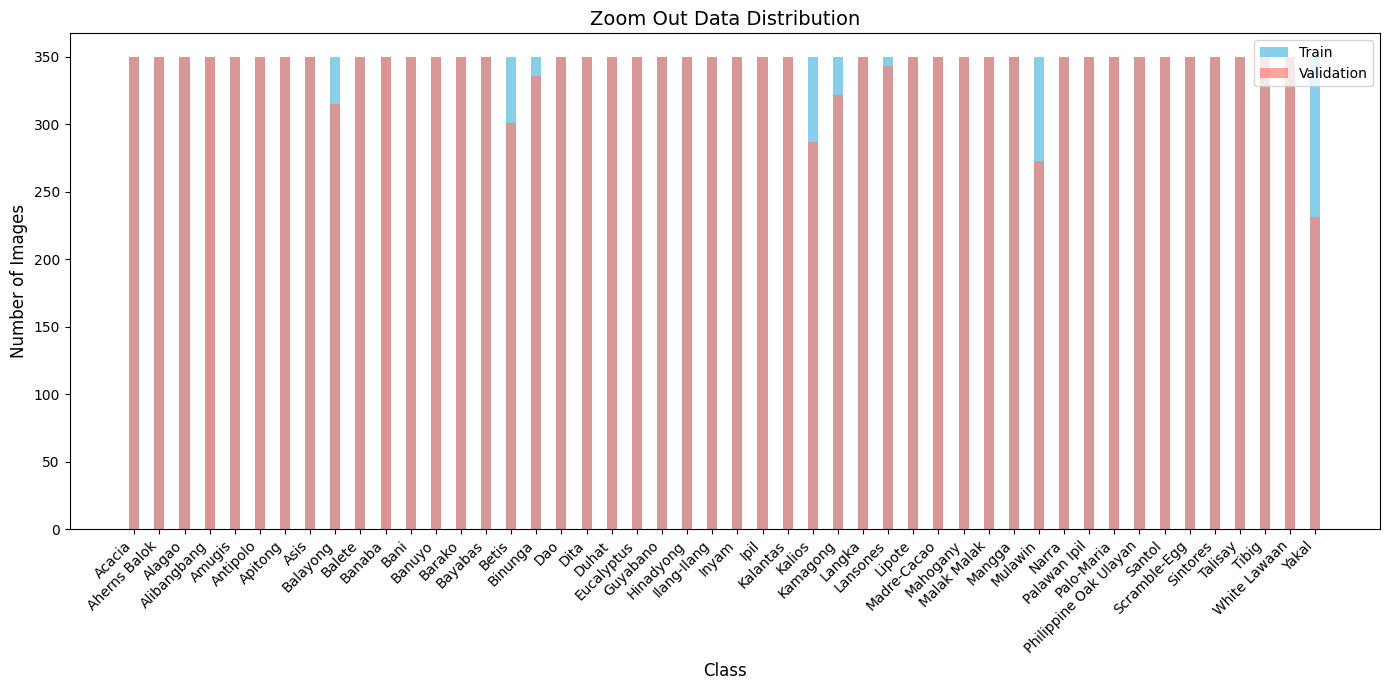

: 

In [ ]:
import os
import matplotlib.pyplot as plt

def count_images_in_classes(base_dir):
    """Count images directly inside each class folder."""
    class_counts = {}
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len([
                f for f in os.listdir(class_path) 
                if os.path.isfile(os.path.join(class_path, f))
            ])
    return dict(sorted(class_counts.items()))

def plot_class_distribution(train_counts, val_counts):
    """Plot class distributions for both train and validation datasets."""
    plt.figure(figsize=(14, 7))
    
    # Plot Train Data
    plt.bar(train_counts.keys(), train_counts.values(), width=0.4, label="Train", color="skyblue")
    
    # Plot Validation Data
    plt.bar(val_counts.keys(), val_counts.values(), width=0.4, 
            label="Validation", color="salmon", alpha=0.7)
    
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.title("Zoom Out Data Distribution", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_dir = r"F:\SNAPFOLIA\TRAIN_ZOOM_IN_CLS"
    val_dir = r"F:\SNAPFOLIA\TEST_ZOOM_IN_CLS"

    train_counts = count_images_in_classes(train_dir)
    val_counts = count_images_in_classes(val_dir)

    plot_class_distribution(train_counts, val_counts)
